# Project 1: Counting words in college subreddits

Due 9/16. Reminder that you are allowed to use any amount of AI assistance or outside resources with citation

## Part 1: word counting and bag of words

In [25]:
#install spacy in the current conda environment
!pip install spacy
import sys
!{sys.executable} -m pip install matplotlib


In [26]:
#download a small language model to help with cleaning tasks
!python -m spacy download en_core_web_sm



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------------------------- ------------- 8.4/12.8 MB 47.2 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 42.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [27]:
#import required libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import spacy
language_model = spacy.load("en_core_web_sm")
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

### Problem 1 and example: common words in the Michigan subreddit

In [28]:
#read the data from a csv file in the folder
mich=pd.read_csv("umich.csv")

In [29]:
#jupyter will print a pretty representation of most python objects if you just put the name
#we can see that the full text of each reddit comment is provided in the "text" column
mich

,Unnamed: 0,date,post_votes,text,user,com_votes
0,0,2024-09-04 15:33:20,2,"Zingermans has a nice reuben, pretty pricey bu...",Suspicious-Bad703,2
1,1,2024-09-04 15:33:20,2,I really love Tomokun!,webstbre000,2
2,2,2024-09-04 15:33:20,2,The Seoul is pretty good I especially like the...,iaxlmao,1
3,3,2024-09-04 15:33:20,2,A lot of it depends on what type of food and w...,I-696,1
4,4,2024-09-04 14:32:17,1,You can book completely enclosed private study...,sneep_,2
...,...,...,...,...,...,...
8334,8334,2024-07-02 12:35:36,9,It isn’t a student org,Vibes_And_Smiles,1
8335,8335,2024-07-02 11:07:10,0,Life \r\nMatter \r\nLife's matter,tctu,8
8336,8336,2024-07-02 11:07:10,0,google,SUPERazkari,4
8337,8337,2024-07-02 11:07:10,0,That’s a hard question to answer for a set of ...,Own-Resident-3837,-1


In [30]:
#this is a function that does some light cleaning, by removing newline characters, converting to lowercase, and removing punctuation

def clean(text):
    #remove newline and space characters
    text = ' '.join(text.split())
    #convert the text to lowercase
    text = text.lower()
    #remove punctuation
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    return text

In [31]:
#pandas allows us to quickly apply this cleaning function to all rows in a column
mich['cleaned_text'] = mich['text'].apply(clean)

In [32]:
#we can see the first comment after cleaning vs before
mich["cleaned_text"][0]

'zingermans has a nice reuben pretty pricey but the sammies are pretty big'

In [33]:
mich["text"][0]

'Zingermans has a nice reuben, pretty pricey but the sammies are pretty big'

In [34]:
#create a bag of words representation with count vectorizer
vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(mich['cleaned_text'])

In [35]:
#this is a sparse matrix, which is a more efficient way to store a matrix with many zeros
#the matrix has 8339 rows (one for each comment) and 15289 columns (one for each unique word in the dataset)
bag_of_words

<8339x15289 sparse matrix of type '<class 'numpy.int64'>'
	with 221217 stored elements in Compressed Sparse Row format>

In [36]:
#create a dataframe from the sparse matrix
#this is a more human-readable way to view the data
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

,aa,aadl,aapd,aata,ab,abab,abandon,abandoned,abbreviation,abbreviations,...,zoned,zones,zoning,zoo,zoom,zoomer,zoomers,zuckerberg,𝓲𝓷𝓼𝓮𝓬𝓾𝓻𝓮,𝘢𝘩𝘦𝘮
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8337,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
#dataframes have a convenient method for summing the values in each column
#this will give us the number of times each word appears in the dataset
word_counts = bow_df.sum()
#we can sort the values to see the most common words
word_counts = word_counts.sort_values(ascending=False)

#notice that the top words are not very informative, as they are common words that appear in many contexts
#and bottom words include a lot of typos and other noise
word_counts

the            11306
to              8480
and             6921
you             6256
of              5028
               ...  
journals           1
journeywhen        1
jpg                1
js                 1
𝘢𝘩𝘦𝘮               1
Length: 15289, dtype: int64

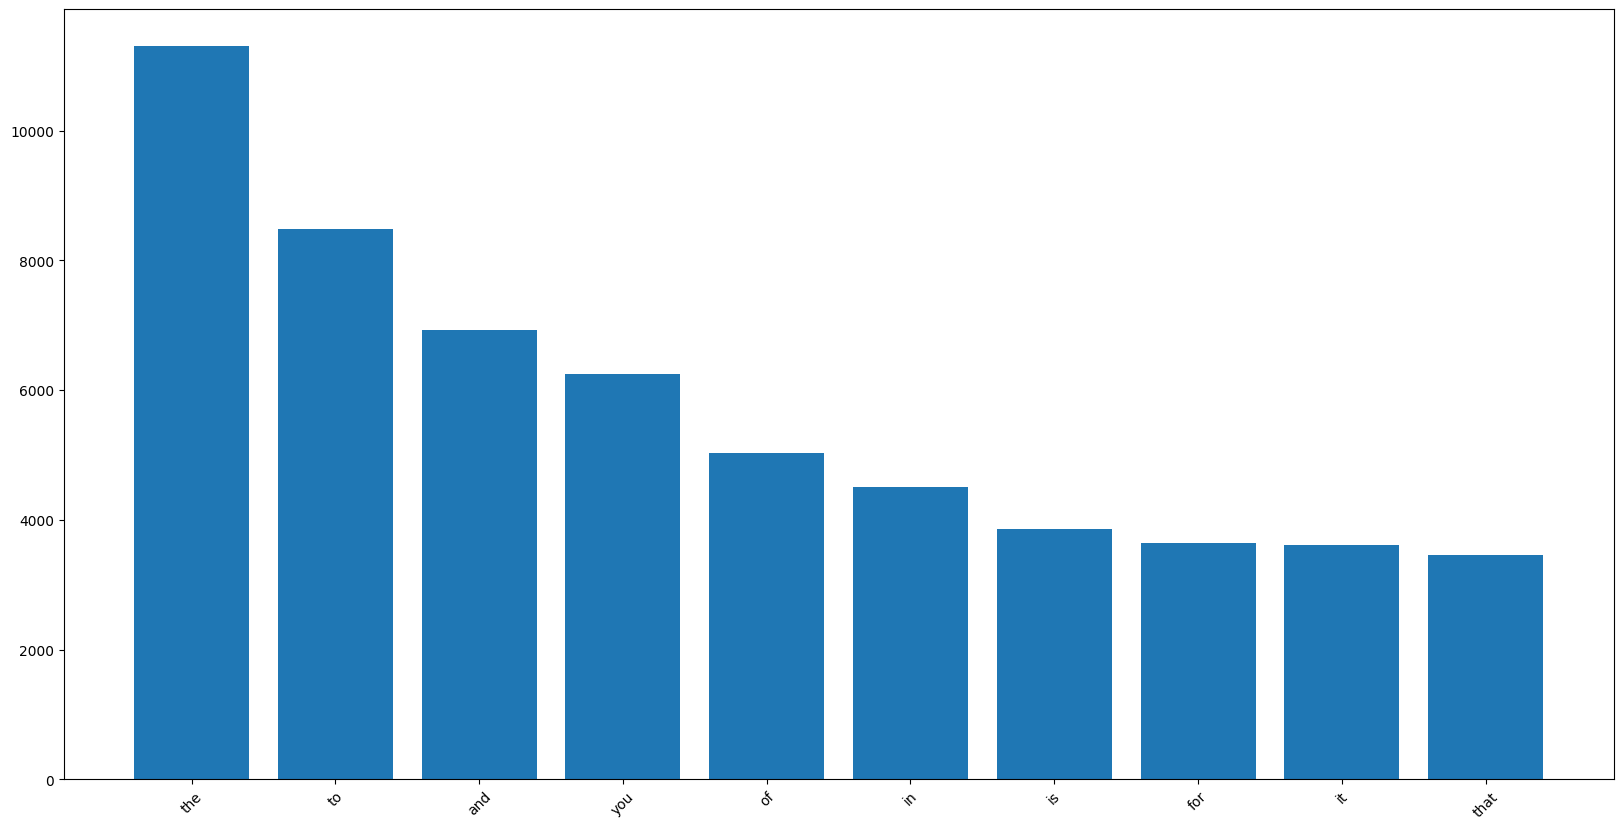

In [38]:
#we can plot the most common words
#we will only plot the top 10 words for readability
word_counts = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(word_counts.index, word_counts.values)
plt.xticks(rotation=45)
plt.show()

#### Question 1: what do you notice about the words in this plot? Is this useful for studying the community?

Answer here: 

#### Lemmatization and stopword removal

In [39]:
#lemmatization function from the openclassrooms reading
def lemmatize(text):

   doc = language_model(text)

   tokens = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]

   return ' '.join(tokens)

In [40]:
#we can further process the text by removing stopwords and lemmatizing
mich['lemmatized_text'] = mich['cleaned_text'].apply(lemmatize)

In [41]:
#count vectorizer also has parameters min_df and max_df that can be used to filter out words that are too rare or too common
#min_df=3 means that a word must appear in at least 3 documents to be included, this will remove typos and rare words
#max_df=0.3 means that a word must appear in at most 30% of documents to be included, this will remove corpus-specific stopwords

#we are also able to include n-grams in the count vectorizer
#n-grams are sequences of n words that appear together in the text
#the n-gram_range parameter specifies the minimum and maximum n-gram size to include (so in this case, we are including both unigrams and bigrams)

vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
bag_of_words = vectorizer.fit_transform(mich['lemmatized_text'])

In [42]:
#we can see that we filtered out 11000 common words and typos
bag_of_words

<8339x8608 sparse matrix of type '<class 'numpy.int64'>'
	with 126768 stored elements in Compressed Sparse Row format>

In [43]:
#we can repeat the previous code to create a dataframe and count the words
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
word_counts = bow_df.sum()
word_counts = word_counts.sort_values(ascending=False)
word_counts

not              2863
student          1183
like             1183
people           1124
class             988
                 ... 
club campus         3
open not            3
open source         3
club activity       3
luck search         3
Length: 8608, dtype: int64

In [44]:
#we can convert this to a percentage instead of an absolute count by dividing by the total number of words
word_counts = word_counts / word_counts.sum()

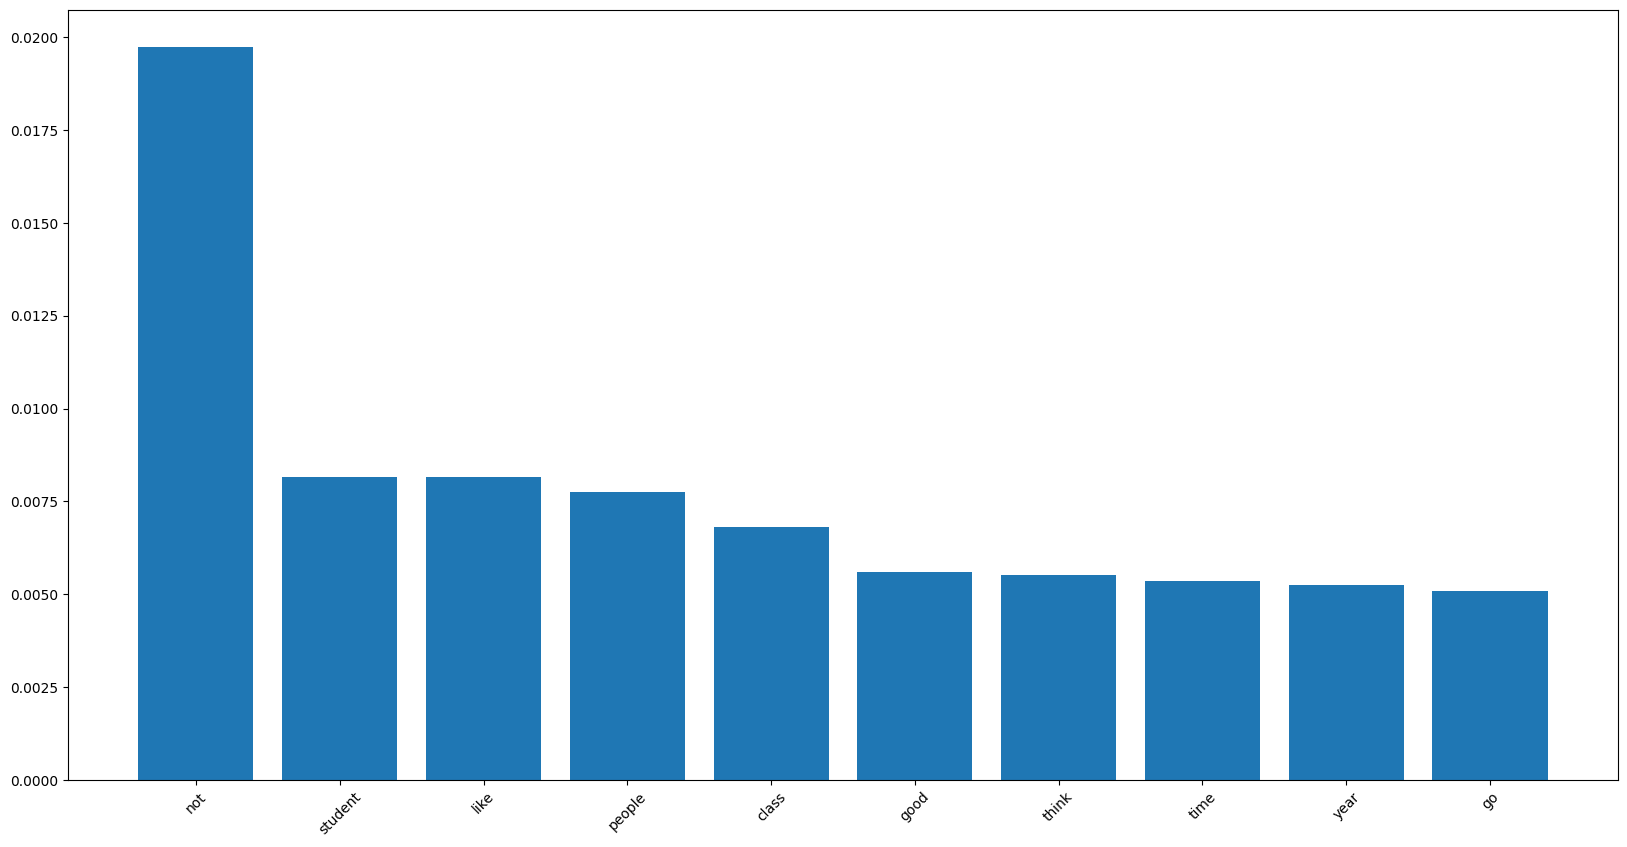

In [45]:
#we can plot the most common words
#we will only plot the top 10 words for readability
plot_list = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

In [46]:
#pandas allows us to access specific words in the series using the index
word_counts["student loan"]

4.1400153180566765e-05

In [47]:
#we can also use a list of words to compare and plot specific words
plot_list=word_counts[["history", "business", "computer science", "cs", "computer"]]
plot_list

history             0.000352
business            0.000600
computer science    0.000035
cs                  0.001228
computer            0.000262
dtype: float64

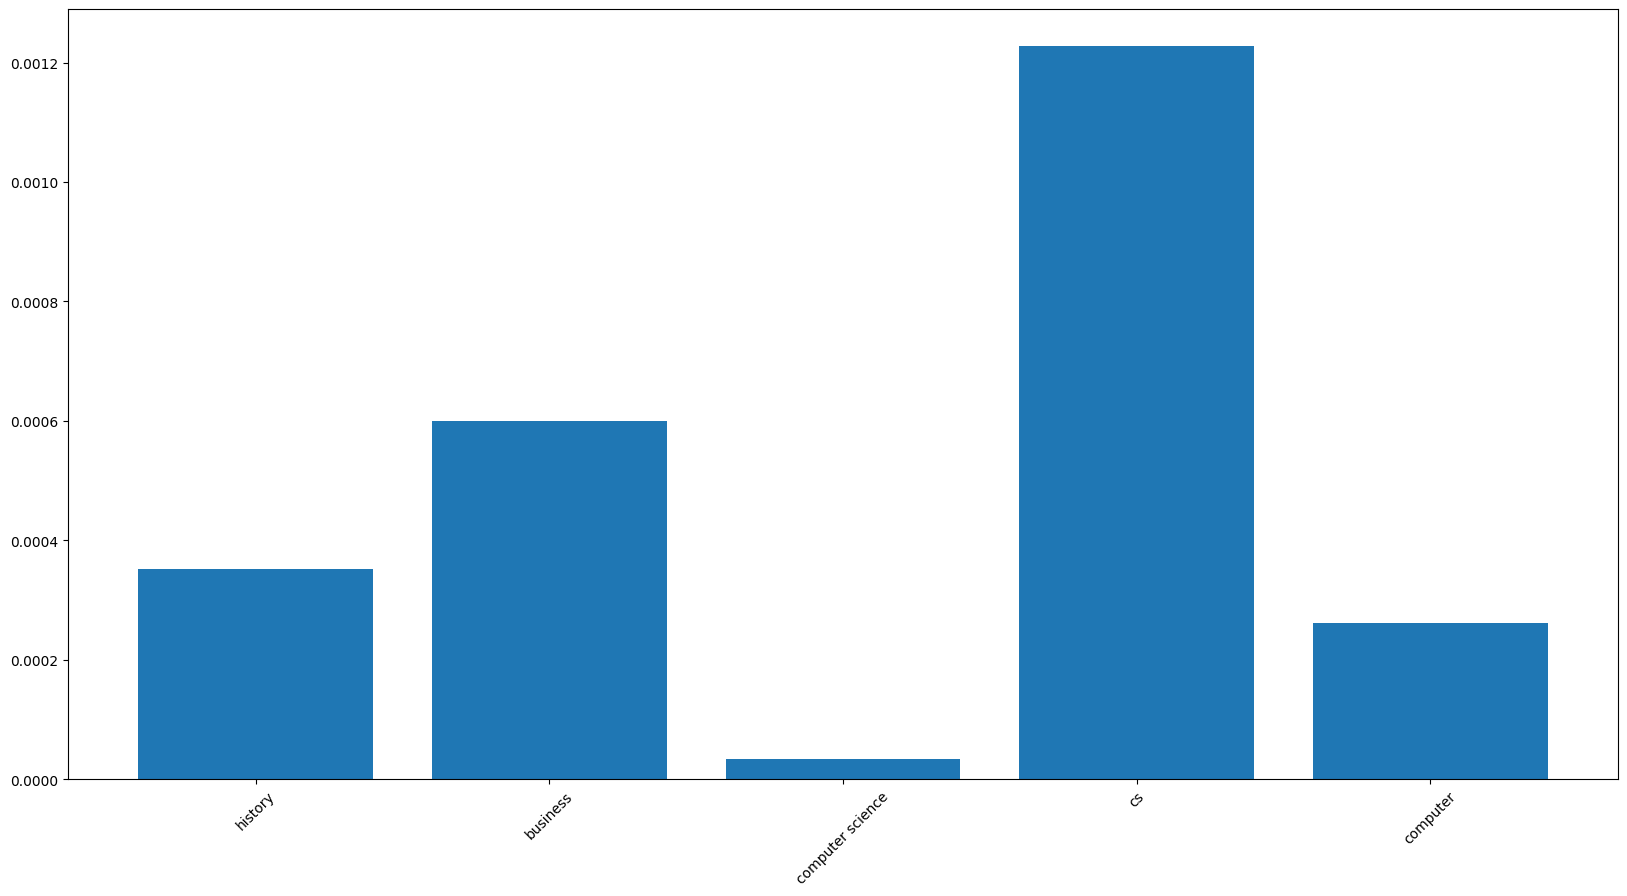

In [48]:

plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

#### Question 2:

In [49]:
#TODO: pick 5 words that you find interesting or are curious about, and plot a bar plot of their frequency in this dataset 

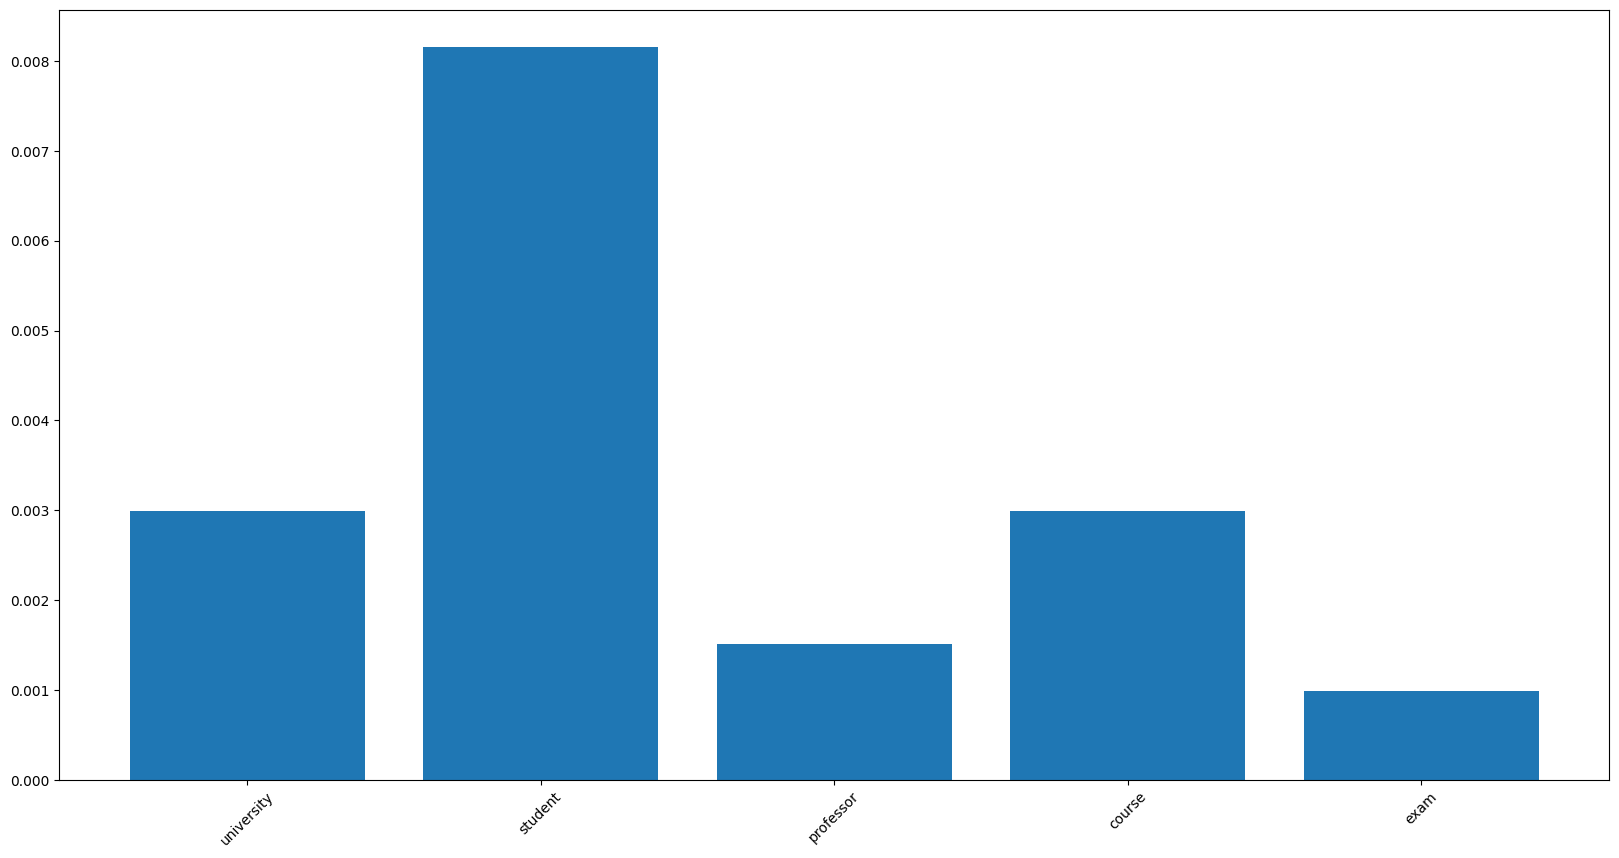

In [50]:
interest_list=word_counts[["university", "student", "professor", "course", "exam"]]
interest_list

plt.figure(figsize=(20,10))
plt.bar(interest_list.index, interest_list.values)
plt.xticks(rotation=45)
plt.show()


### Problem 2: repeat this process with the Illinois subreddit data (in this directory as "uiuc.csv"). You should not have to change too much in the previous code besides the dataframe path and name. Your notebook should include the two bar graphs including and excluding stopwords. Use the same 5 words and compare their relative frequency between the two subreddits. Discuss any interesting differences you notice in a short markdown cell. 

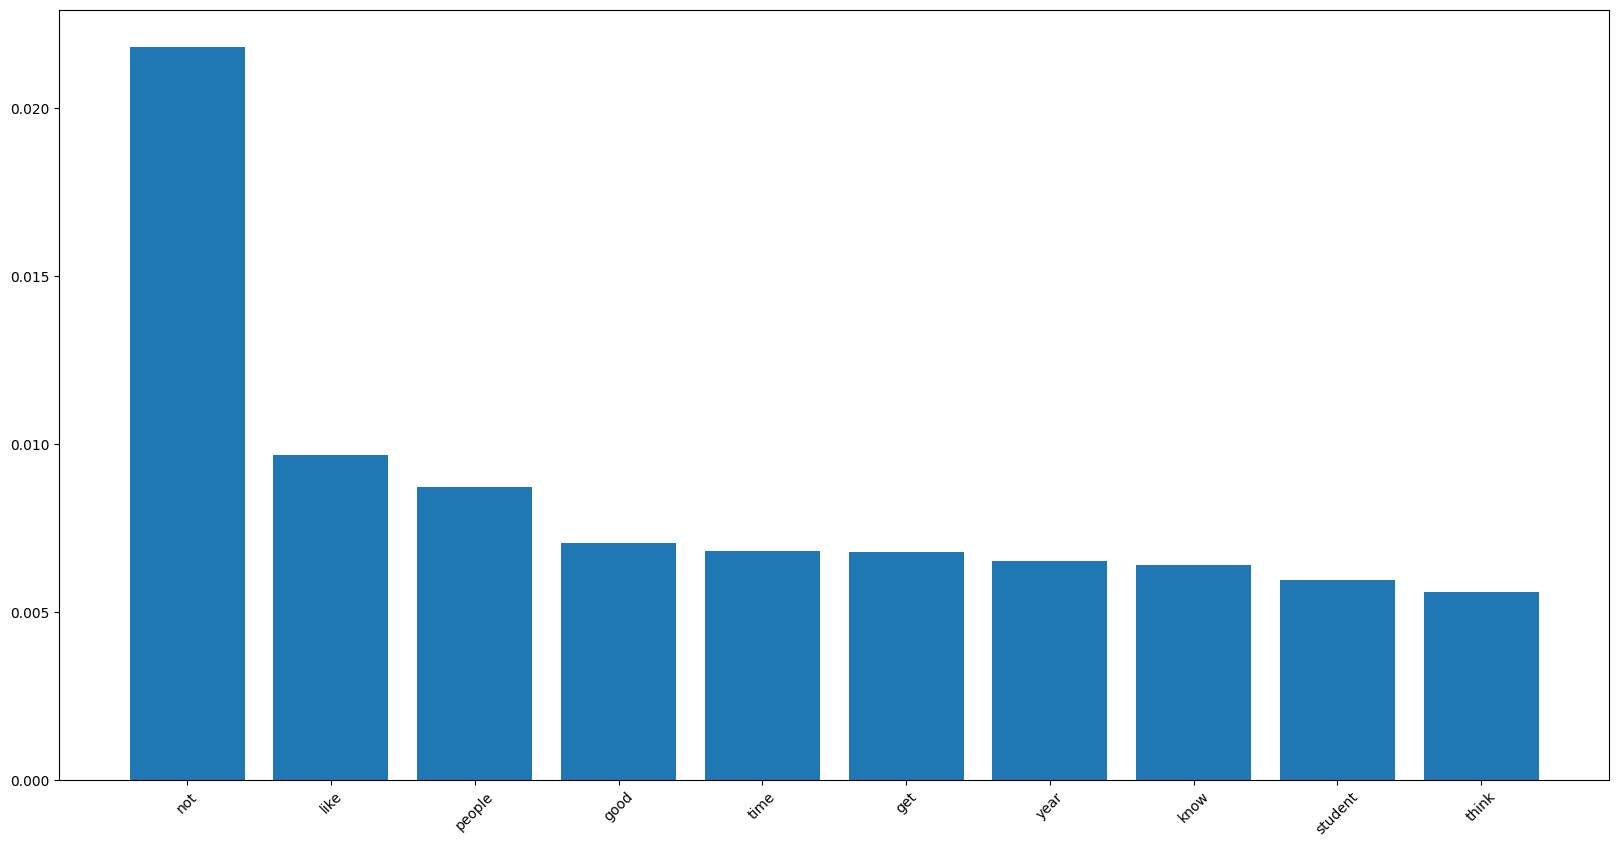

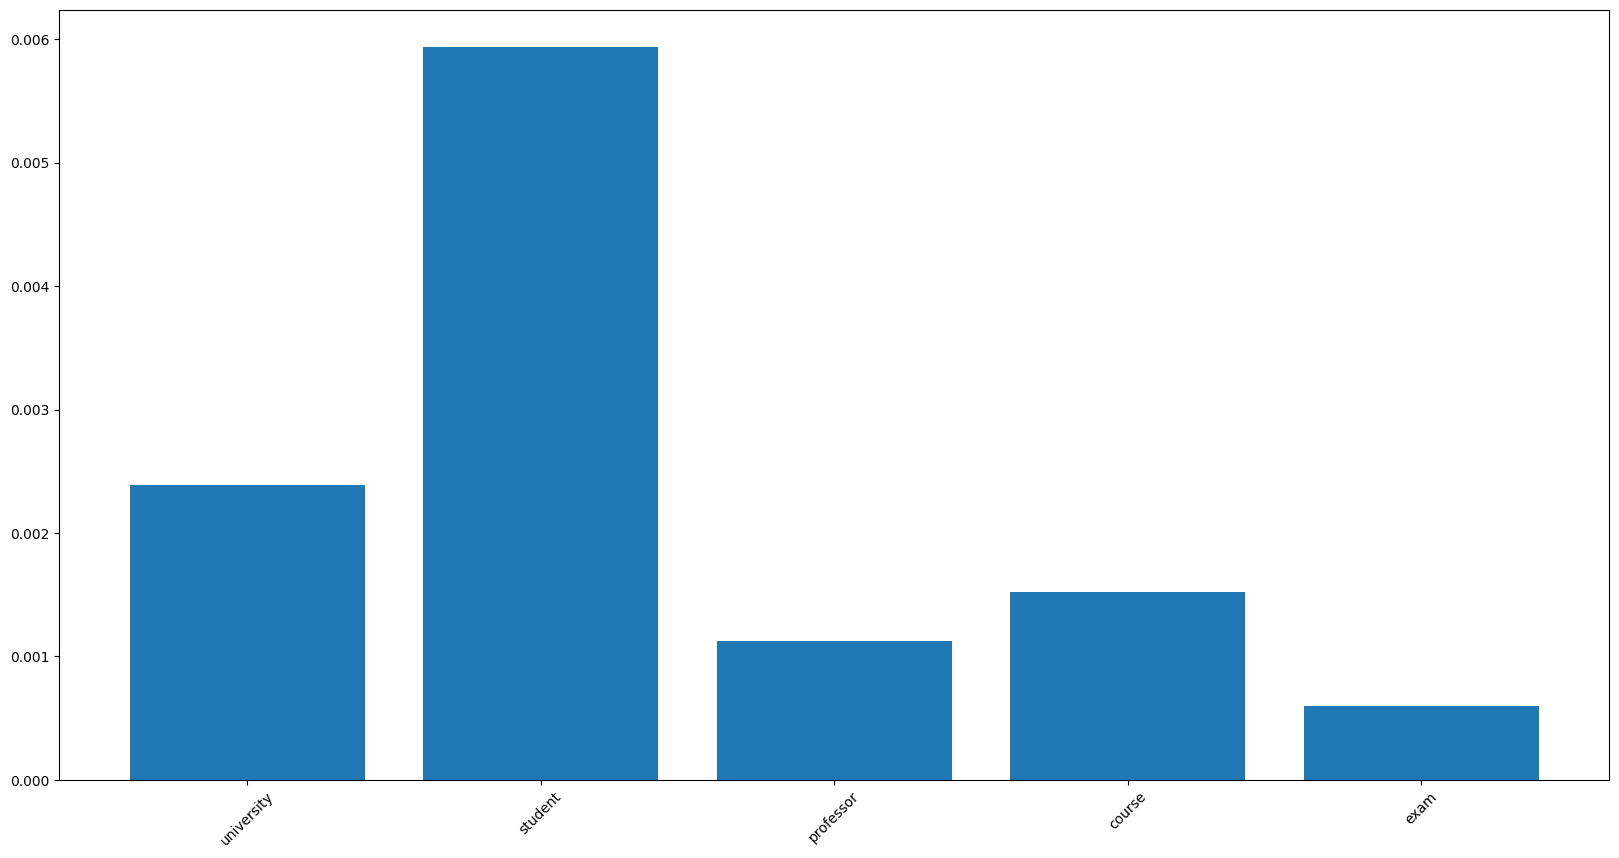

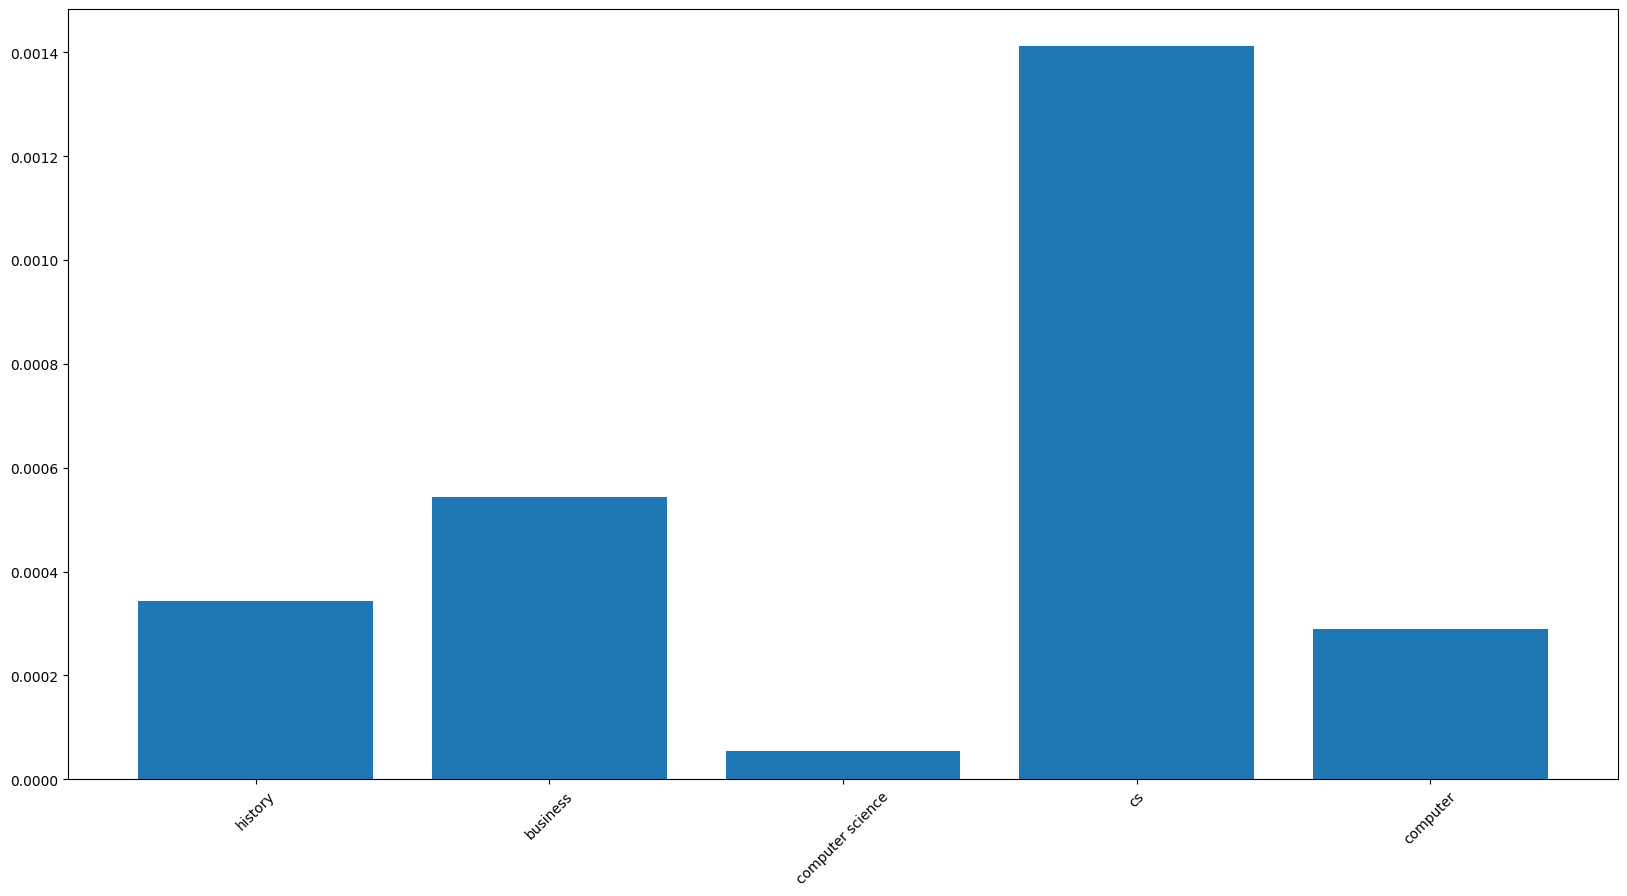

In [53]:
uiuc=pd.read_csv("uiuc.csv")
uiuc

def clean(text):
  
    text = ' '.join(text.split())
  
    text = text.lower()
   
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    return text

uiuc['cleaned_text'] = uiuc['text'].apply(clean)
uiuc['cleaned_text'][0]
uiuc['text'][0]

vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(uiuc['cleaned_text'])

bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

word_counts = bow_df.sum()
word_counts = word_counts.sort_values(ascending=False)
word_counts

def lemmatize(text):

   doc = language_model(text)
   tokens = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]

   return ' '.join(tokens)

uiuc['lemmatized_text'] = uiuc['cleaned_text'].apply(lemmatize)
vectorizer = CountVectorizer(min_df=3, max_df=0.2, ngram_range=(1,2))
bag_of_words = vectorizer.fit_transform(uiuc['lemmatized_text'])

bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
word_counts = bow_df.sum()
word_counts = word_counts.sort_values(ascending=False)
word_counts

word_counts = word_counts / word_counts.sum()

plot_list = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

plot_list=word_counts[["university", "student", "professor", "course", "exam"]]


plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

plot_2=word_counts[["history", "business", "computer science", "cs", "computer"]]


plt.figure(figsize=(20,10))
plt.bar(plot_2.index, plot_2.values)
plt.xticks(rotation=45)
plt.show()


I used Chatgpt to solve this problem.

### Problem 3: using the provided combined dataframe, train a logistic regression model using the sklearn Logistic Regression implementation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html. Create a bag of words table from the combined data, and use that along with the "label" column to train the classifier. Please try this out and be prepared with issues or questions next Monday. We will be discussing in class

In [54]:
uiuc=pd.read_csv("uiuc.csv")
mich=pd.read_csv("umich.csv")

#sample so we have even number of samples from each dataset
mich=mich.sample(n=4725)

#assign labels based on origin subreddit of comment
uiuc['label']=1
mich['label']=0

#you will be working with the data csv for the rest of the question
data=pd.concat([uiuc,mich])
data

,Unnamed: 0,date,post_votes,text,user,com_votes,label
0,0,2024-09-04 14:43:40,2,Have the same professor! And in lecture he did...,zhen3441,2,1
1,1,2024-09-04 14:43:40,2,Do you find it helpful to still go to the lect...,Kai2747,1,1
2,2,2024-09-04 12:52:08,3,Have you tried emailing University Housing to ...,TurboBKTastic,2,1
3,3,2024-09-04 12:52:08,3,Purchasing Illini Cash should get you added to...,HoosierCAB,2,1
4,4,2024-09-04 12:52:08,3,"Just did, thanks for the suggestion! It hadn't...",Sector-Both,1,1
...,...,...,...,...,...,...,...
527,527,2024-09-01 20:08:39,3,https://www.instagram.com/stephkaycreations?ig...,vande924,1,0
4523,4523,2024-08-10 00:28:57,84,Will edit this comment when i’m home from vaca...,tylerfioritto,1,0
7633,7633,2024-07-11 21:18:55,0,"Honestly, this is a really solid schedule. I d...",seabass0415,2,0
7819,7819,2024-07-09 18:12:02,3,https://kb.housing.umich.edu/hc/en-us/articles...,Own-Resident-3837,2,0


In [55]:
#clean and lemmatize the data csv
data['cleaned_text'] = data['text'].apply(lambda x: lemmatize(clean(x)))

In [56]:
#create a bag of words representation with count vectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['cleaned_text'])

y = data['label']

In [57]:
#train a logistic regression model using the bag of words features as X and the label column as y
log = LogisticRegression()
log.fit(X, y)

y_pred = log.predict(X)

In [58]:
#report the accuracy of the model
accuracy = accuracy_score(y, y_pred)
accuracy

0.905079365079365

#### Part 2: hold out part of the dataset using sklearn train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Pass in your previously generated bag of words as X and the label column as y. Use only the X_train and y_train for training and hold out the X_test and y_test to score the model on unseen data.

In [ ]:
# what is the accuracy of the model? Is it better or worse than previous?Why do you think it has changed? 

The accuracy of the model on the test set is 90.36%, which is significantly better than the previous accuracy of 71.69%. This improvement could be due to better preprocessing, a more effective data split, or a change in feature extraction, but it’s also important to check for potential overfitting or data leakage.

#### Part 3: Examine the top features of your model using the following code

In [ ]:
#get the coefficients of the model and plot the top 10 most positive and top 10 most negative coefficients
#what do you notice about these words? Are they surprising or expected?


In [59]:
feature_names = vectorizer.get_feature_names_out()

# Get coefficients from the trained model
coefficients = pd.DataFrame({'feature': feature_names, 'coefficient': log.coef_[0]})

# Sort by coefficient values
coefficients = coefficients.sort_values('coefficient', ascending=False)

# Get top 10 positive and negative features
top_10_positive = coefficients.head(10)
top_10_negative = coefficients.tail(10)

print(top_10_positive)

print(top_10_negative)


          feature  coefficient
11622        uiuc     2.950712
9621          rso     2.594327
5591     illinois     2.114429
4583     grainger     2.078163
5586       illini     2.072276
1698    champaign     2.035465
11912      urbana     2.035127
2623     danville     1.852251
933    basketball     1.844548
6384          las     1.834697
        feature  coefficient
2514        csg    -1.830171
6937      mcard    -2.023963
12161  waitlist    -2.093676
2890       diag    -2.124946
3354        eec    -2.151205
11644        um    -2.186381
11141     texas    -2.384098
11650     umich    -2.573278
4201     fresno    -2.772897
7100   michigan    -3.066570


In [ ]:
#examine these words and see if they make sense. Do they differentiate UIUC from another university?

Yes, these words effectively differentiate UIUC from another university, specifically the University of Michigan.

### Problem 4: Train a 10 topic topic model from the UIUC subreddit data using Gensim LDA. (https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html) If you get here before Wednesday 9/11, don't rush to finish, but feel free to continue ahead. We will go through this in class. Print out the top words in each topic, and read through the words for each topic to decide the theme of the topic: remember this is subjective and there are no right or wrong answers. Print out a few comments with high frequencies of each topic and analyze if your topic labels were representative. 

In [60]:
!pip install gensim

In [61]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.matutils import Sparse2Corpus
from sklearn.feature_extraction.text import CountVectorizer




In [62]:
corpus = Sparse2Corpus(X, documents_columns=False)
id2word = dict((v, k) for k, v in vectorizer.vocabulary_.items())

In [63]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_model.print_topics()

[(0,
  '0.037*"sell" + 0.014*"ra" + 0.012*"interested" + 0.010*"not" + 0.010*"county" + 0.009*"card" + 0.008*"market" + 0.007*"rough" + 0.007*"usc" + 0.007*"rd"'),
 (1,
  '0.019*"math" + 0.019*"course" + 0.014*"not" + 0.013*"student" + 0.013*"year" + 0.013*"class" + 0.012*"cs" + 0.012*"major" + 0.010*"eec" + 0.009*"job"'),
 (2,
  '0.030*"not" + 0.022*"class" + 0.016*"people" + 0.012*"like" + 0.011*"semester" + 0.009*"student" + 0.009*"know" + 0.008*"club" + 0.008*"ticket" + 0.008*"work"'),
 (3,
  '0.018*"get" + 0.016*"michigan" + 0.015*"like" + 0.014*"not" + 0.014*"people" + 0.009*"friend" + 0.009*"student" + 0.009*"lot" + 0.008*"campus" + 0.007*"go"'),
 (4,
  '0.016*"not" + 0.015*"texas" + 0.012*"stat" + 0.011*"class" + 0.011*"think" + 0.010*"like" + 0.010*"question" + 0.010*"people" + 0.009*"week" + 0.009*"problem"'),
 (5,
  '0.022*"not" + 0.012*"people" + 0.011*"like" + 0.010*"work" + 0.009*"fund" + 0.009*"lot" + 0.009*"student" + 0.008*"study" + 0.008*"class" + 0.007*"know"'),
 (6,

In [64]:
import textwrap

pd.set_option('display.max_colwidth', None)
toprint=mich["text"][30]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)

Certainly won't make a difference career wise. 99% of people in data science
don't need anything beyond "what is a gradient". If you just want to learn the
material better then sure 285 might have higher teaching quality


In [65]:
lda_model.get_document_topics(corpus[1])

[(0, 0.26798734),
 (1, 0.010006771),
 (2, 0.43622774),
 (3, 0.010006054),
 (4, 0.22573377),
 (5, 0.0100091295),
 (6, 0.010010091),
 (7, 0.01000559),
 (8, 0.010006378),
 (9, 0.010007094)]

In [66]:
models=lda_model.get_document_topics(corpus, minimum_probability=0)
rows=[]

for i in range(len(models)):
    row=[]
    for m in models[i]:
        row.append(m[1])
    rows.append(row)

topic_df=pd.DataFrame(rows)
topic_df.sort_values(3, ascending=False)

,0,1,2,3,4,5,6,7,8,9
1552,0.002341,0.002342,0.002342,0.978924,0.002342,0.002342,0.002342,0.002341,0.002342,0.002342
1564,0.002387,0.002387,0.002387,0.978518,0.002387,0.002387,0.002387,0.002387,0.002387,0.002387
1148,0.002430,0.002430,0.002431,0.978126,0.002430,0.002430,0.002431,0.002430,0.002430,0.002430
1539,0.002961,0.002962,0.002962,0.973344,0.002962,0.002962,0.002962,0.002962,0.002962,0.002962
1369,0.003227,0.003229,0.003228,0.970950,0.003227,0.003228,0.003228,0.003228,0.003228,0.003228
...,...,...,...,...,...,...,...,...,...,...
7829,0.018826,0.000743,0.071474,0.000743,0.167092,0.269562,0.145786,0.000743,0.098882,0.226149
899,0.000581,0.077663,0.009178,0.000581,0.000581,0.010007,0.152190,0.000581,0.748056,0.000581
5118,0.060340,0.019441,0.559572,0.000525,0.095821,0.048413,0.080317,0.073873,0.061175,0.000525
7023,0.020196,0.031927,0.455668,0.000498,0.139937,0.131987,0.121440,0.000498,0.041242,0.056607
